# Why does USI 10 ms give different result?

## Is it due to the difference in test cases?

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import glob, os

def compile_results(path,cases,max_run_num,filename="Broadcast_Metrics.csv"):
    """
    Given the root path for results, get the results for each scenario in a DF
    filename is the CSV file name to look for under each scenario folder
    max_run_num is the max run number to ider
    """
    df_list = []
    for case in cases:
        scenarios = glob.glob(os.path.join(path, case, "*"))
        for scenario in scenarios:
            df = pd.read_csv(os.path.join(scenario, filename))
            df = df.loc[df["Run"]<=max_run_num]
            df["Scenario"] = scenario.split("/")[-1]
            df_list.append(df)
    return pd.concat(df_list)

def compile_results_range(path,cases,start_run_num,end_run_num,filename="Broadcast_Metrics.csv"):
    """
    Given the root path for results, get the results for each scenario in a DF
    filename is the CSV file name to look for under each scenario folder
    max_run_num is the max run number to ider
    """
    df_list = []
    for case in cases:
        scenarios = glob.glob(os.path.join(path, case, "*"))
        for scenario in scenarios:
            df = pd.read_csv(os.path.join(scenario, filename))
            df = df.loc[(df["Run"]>=start_run_num) & (df["Run"]<=end_run_num)]
            df["Scenario"] = scenario.split("/")[-1]
            df_list.append(df)
    return pd.concat(df_list)

def compile_results_range_testcase(path,cases,start_run_num,end_run_num,test_cases,filename="Broadcast_Metrics.csv"):
    """
    Given the root path for results, get the results for each scenario in a DF
    filename is the CSV file name to look for under each scenario folder
    max_run_num is the max run number to ider
    test_cases is a list of test cases to include, specify on speed, height, bitrate (e.g. [UAVSpeed-16_Height-150_BitRate-13, UAVSpeed-16_Height-150_BitRate-13, ...])
    """
    df_list = []
    for case in cases:
        scenarios = glob.glob(os.path.join(path, case, "*"))
        scenarios = [scenario for scenario in scenarios if any([test_case in scenario for test_case in test_cases])]
        for scenario in scenarios:
            df = pd.read_csv(os.path.join(scenario, filename))
            df = df.loc[(df["Run"]>=start_run_num) & (df["Run"]<=end_run_num)]
            df["Scenario"] = scenario.split("/")[-1]
            df_list.append(df)
    return pd.concat(df_list)

1761
5283
6000
5434
5957
5994
1761
5283
6000
5434
5957
5994


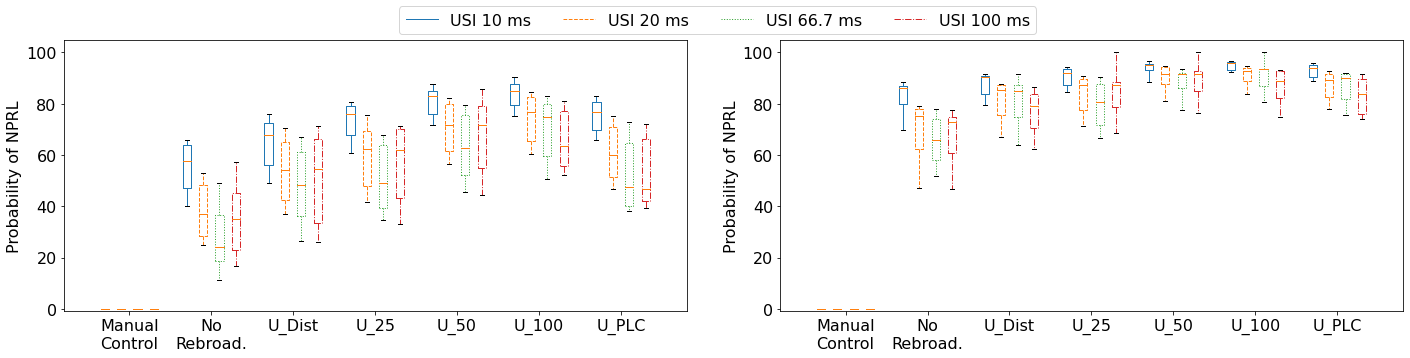

In [5]:
# Plot Percentage of Sim Runs with Consecutive Packet Failures
MANUAL_PATH = "/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Obj3_Retransmission_Datasets/Manual_{}_Interference_new"
WAYPOINT_PATH = "/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Obj3_Retransmission_Datasets/Waypoint_Only_{}_Interference_new"
FP_25_PATH = "/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Obj3_Retransmission_Datasets/U_Fixed25_{}_Interference_new"
FP_50_PATH = "/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Obj3_Retransmission_Datasets/U_Fixed50_{}_Interference_new"
FP_100_PATH = "/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Obj3_Retransmission_Datasets/U_Fixed100_{}_Interference_new"
DV_PATH = "/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Obj3_Retransmission_Datasets/U_Dist_{}_Interference_new"
TH_PATH = "/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Obj3_Retransmission_Datasets/U_PLC_{}_Interference_new"
CASES = ["uav_scenario_0_processed", "uav_scenario_1_processed", "uav_scenario_2_processed",
         "manet_scenario_1_processed", "manet_scenario_a_processed", "manet_scenario_2_processed"]
TEST_CASES = ["UAVSpeed-16_Height-60_BitRate-26", "UAVSpeed-26_Height-150_BitRate-26", "UAVSpeed-26_Height-60_BitRate-65", # These are for UAV scenarios
              "UAVSpeed-16_BitRate-26_Height-60", "UAVSpeed-26_BitRate-26_Height-150", "UAVSpeed-26_BitRate-65_Height-60"] # These are for MANET. They are the same scenarios, the naming convention was different
MAX_RUN_NUM = 499 # Run num starts at 0
START_RUN_NUM = 0
END_RUN_NUM = 499
N_SECS = 2

# To store the percentage of sim runs with no cons packet failures
manual_result = []
waypoint_result = []
fp_25_result = []
fp_50_result = []
fp_100_result = []
dv_result = []
pm_result = []
# pm_gcs_result = []

for case in CASES:
    if "uav" in case:
        intf_type = "UAV"
    elif "manet" in case:
        intf_type = "MANET"
    # manual_df = compile_results(MANUAL_PATH.format(intf_type), [case], MAX_RUN_NUM, "Cons_Fail_{}_period.csv".format(N_SECS))
    # waypoint_df = compile_results(WAYPOINT_PATH.format(intf_type), [case], MAX_RUN_NUM, "Cons_Fail_{}_period.csv".format(N_SECS))
    # fp_25_df = compile_results(FP_25_PATH.format(intf_type), [case], MAX_RUN_NUM, "Cons_Fail_{}_period.csv".format(N_SECS))
    # fp_50_df = compile_results(FP_50_PATH.format(intf_type), [case], MAX_RUN_NUM, "Cons_Fail_{}_period.csv".format(N_SECS))
    # fp_100_df = compile_results(FP_100_PATH.format(intf_type), [case], MAX_RUN_NUM, "Cons_Fail_{}_period.csv".format(N_SECS))
    # dv_df = compile_results(DV_PATH.format(intf_type), [case], MAX_RUN_NUM, "Cons_Fail_{}_period.csv".format(N_SECS))
    # pm_df = compile_results(TH_PATH.format(intf_type), [case], MAX_RUN_NUM, "Cons_Fail_{}_period.csv".format(N_SECS))
    '''For Custom Run Num Range'''
    manual_df = compile_results_range_testcase(MANUAL_PATH.format(intf_type), [case], START_RUN_NUM, END_RUN_NUM, TEST_CASES, "Cons_Fail_{}_period.csv".format(N_SECS))
    waypoint_df = compile_results_range_testcase(WAYPOINT_PATH.format(intf_type), [case], START_RUN_NUM, END_RUN_NUM, TEST_CASES, "Cons_Fail_{}_period.csv".format(N_SECS))
    fp_25_df = compile_results_range_testcase(FP_25_PATH.format(intf_type), [case], START_RUN_NUM, END_RUN_NUM, TEST_CASES, "Cons_Fail_{}_period.csv".format(N_SECS))
    fp_50_df = compile_results_range_testcase(FP_50_PATH.format(intf_type), [case], START_RUN_NUM, END_RUN_NUM, TEST_CASES, "Cons_Fail_{}_period.csv".format(N_SECS))
    fp_100_df = compile_results_range_testcase(FP_100_PATH.format(intf_type), [case], START_RUN_NUM, END_RUN_NUM, TEST_CASES, "Cons_Fail_{}_period.csv".format(N_SECS))
    dv_df = compile_results_range_testcase(DV_PATH.format(intf_type), [case], START_RUN_NUM, END_RUN_NUM, TEST_CASES, "Cons_Fail_{}_period.csv".format(N_SECS))
    pm_df = compile_results_range_testcase(TH_PATH.format(intf_type), [case], START_RUN_NUM, END_RUN_NUM, TEST_CASES, "Cons_Fail_{}_period.csv".format(N_SECS))
    print(len(pm_df))
    '''Filter out runs where there are NaN results (invalid)'''
    # First, sort all DFs so that their rows are of the same simulation cases
    manual_df.sort_values(by=["Scenario", "Run"], inplace=True)
    waypoint_df.sort_values(by=["Scenario", "Run"], inplace=True)
    fp_25_df.sort_values(by=["Scenario", "Run"], inplace=True)
    fp_50_df.sort_values(by=["Scenario", "Run"], inplace=True)
    fp_100_df.sort_values(by=["Scenario", "Run"], inplace=True)
    dv_df.sort_values(by=["Scenario", "Run"], inplace=True)
    pm_df.sort_values(by=["Scenario", "Run"], inplace=True)
    # pm_gcs_df.sort_values(by=["Scenario", "Run"], inplace=True)

    manual_df.reset_index(inplace=True)
    waypoint_df.reset_index(inplace=True)
    fp_25_df.reset_index(inplace=True)
    fp_50_df.reset_index(inplace=True)
    fp_100_df.reset_index(inplace=True)
    dv_df.reset_index(inplace=True)
    pm_df.reset_index(inplace=True)
    # pm_gcs_df.reset_index(inplace=True)

    runs_nan = (manual_df.isnull().any(axis=1).to_numpy()) | (waypoint_df.isnull().any(axis=1).to_numpy()) | (fp_25_df.isnull().any(axis=1).to_numpy()) | \
            (fp_50_df.isnull().any(axis=1).to_numpy()) | (fp_100_df.isnull().any(axis=1).to_numpy()) | (dv_df.isnull().any(axis=1).to_numpy()) | (pm_df.isnull().any(axis=1).to_numpy())
    manual_df_fil = manual_df.loc[~(runs_nan)]
    waypoint_df_fil = waypoint_df.loc[~(runs_nan)]
    fp_25_df_fil = fp_25_df.loc[~(runs_nan)]
    fp_50_df_fil = fp_50_df.loc[~(runs_nan)]
    fp_100_df_fil = fp_100_df.loc[~(runs_nan)]
    dv_df_fil = dv_df.loc[~(runs_nan)]
    pm_df_fil = pm_df.loc[~(runs_nan)]
    # pm_gcs_df_fil = pm_gcs_df.loc[~(runs_nan)]

    '''For each scheme, for each USI, Get percentages of sim runs with N_SECS consecutive packet failure in at least one uplink'''
    manual_result_usi = [] # These are to store results per USI for the current scenario
    waypoint_result_usi = []
    fp_25_result_usi = []
    fp_50_result_usi = []
    fp_100_result_usi = []
    dv_result_usi = []
    pm_result_usi = []
    for usi in ["10", "20", "66.7", "100"]:
        manual_df_usi = manual_df_fil.loc[(manual_df_fil['Scenario'].str.contains("_UAVSendingInterval-{}_".format(usi)))]
        manual_result_usi.append(len(manual_df_usi.loc[(manual_df_usi["UAV_0_Cons_Fail"] == 0) &
                                            (manual_df_usi["UAV_1_Cons_Fail"] == 0) & (manual_df_usi["UAV_2_Cons_Fail"] == 0) &
                                            (manual_df_usi["UAV_3_Cons_Fail"] == 0) & (manual_df_usi["UAV_4_Cons_Fail"] == 0) & 
                                            (manual_df_usi["UAV_5_Cons_Fail"] == 0) & (manual_df_usi["UAV_6_Cons_Fail"] == 0) & 
                                            (manual_df_usi["UAV_7_Cons_Fail"] == 0)])/len(manual_df_usi) * 100)
        waypoint_df_usi = waypoint_df_fil.loc[(waypoint_df_fil['Scenario'].str.contains("_UAVSendingInterval-{}_".format(usi)))]
        waypoint_result_usi.append(len(waypoint_df_usi.loc[(waypoint_df_usi["UAV_0_Cons_Fail"] == 0) &
                                            (waypoint_df_usi["UAV_1_Cons_Fail"] == 0) & (waypoint_df_usi["UAV_2_Cons_Fail"] == 0) &
                                            (waypoint_df_usi["UAV_3_Cons_Fail"] == 0) & (waypoint_df_usi["UAV_4_Cons_Fail"] == 0) & 
                                            (waypoint_df_usi["UAV_5_Cons_Fail"] == 0) & (waypoint_df_usi["UAV_6_Cons_Fail"] == 0) & 
                                            (waypoint_df_usi["UAV_7_Cons_Fail"] == 0)])/len(waypoint_df_usi) * 100)
        fp_25_df_usi = fp_25_df_fil.loc[(fp_25_df_fil['Scenario'].str.contains("_UAVSendingInterval-{}_".format(usi)))]
        fp_25_result_usi.append(len(fp_25_df_usi.loc[(fp_25_df_usi["UAV_0_Cons_Fail"] == 0) &
                                            (fp_25_df_usi["UAV_1_Cons_Fail"] == 0) & (fp_25_df_usi["UAV_2_Cons_Fail"] == 0) &
                                            (fp_25_df_usi["UAV_3_Cons_Fail"] == 0) & (fp_25_df_usi["UAV_4_Cons_Fail"] == 0) & 
                                            (fp_25_df_usi["UAV_5_Cons_Fail"] == 0) & (fp_25_df_usi["UAV_6_Cons_Fail"] == 0) & 
                                            (fp_25_df_usi["UAV_7_Cons_Fail"] == 0)])/len(fp_25_df_usi) * 100)
        fp_50_df_usi = fp_50_df_fil.loc[(fp_50_df_fil['Scenario'].str.contains("_UAVSendingInterval-{}_".format(usi)))]
        fp_50_result_usi.append(len(fp_50_df_usi.loc[(fp_50_df_usi["UAV_0_Cons_Fail"] == 0) &
                                            (fp_50_df_usi["UAV_1_Cons_Fail"] == 0) & (fp_50_df_usi["UAV_2_Cons_Fail"] == 0) &
                                            (fp_50_df_usi["UAV_3_Cons_Fail"] == 0) & (fp_50_df_usi["UAV_4_Cons_Fail"] == 0) & 
                                            (fp_50_df_usi["UAV_5_Cons_Fail"] == 0) & (fp_50_df_usi["UAV_6_Cons_Fail"] == 0) & 
                                            (fp_50_df_usi["UAV_7_Cons_Fail"] == 0)])/len(fp_50_df_usi) * 100)
        fp_100_df_usi = fp_100_df_fil.loc[(fp_100_df_fil['Scenario'].str.contains("_UAVSendingInterval-{}_".format(usi)))]
        fp_100_result_usi.append(len(fp_100_df_usi.loc[(fp_100_df_usi["UAV_0_Cons_Fail"] == 0) &
                                            (fp_100_df_usi["UAV_1_Cons_Fail"] == 0) & (fp_100_df_usi["UAV_2_Cons_Fail"] == 0) &
                                            (fp_100_df_usi["UAV_3_Cons_Fail"] == 0) & (fp_100_df_usi["UAV_4_Cons_Fail"] == 0) & 
                                            (fp_100_df_usi["UAV_5_Cons_Fail"] == 0) & (fp_100_df_usi["UAV_6_Cons_Fail"] == 0) & 
                                            (fp_100_df_usi["UAV_7_Cons_Fail"] == 0)])/len(fp_100_df_usi) * 100)
        dv_df_usi = dv_df_fil.loc[(dv_df_fil['Scenario'].str.contains("_UAVSendingInterval-{}_".format(usi)))]
        dv_result_usi.append(len(dv_df_usi.loc[(dv_df_usi["UAV_0_Cons_Fail"] == 0) &
                                            (dv_df_usi["UAV_1_Cons_Fail"] == 0) & (dv_df_usi["UAV_2_Cons_Fail"] == 0) &
                                            (dv_df_usi["UAV_3_Cons_Fail"] == 0) & (dv_df_usi["UAV_4_Cons_Fail"] == 0) & 
                                            (dv_df_usi["UAV_5_Cons_Fail"] == 0) & (dv_df_usi["UAV_6_Cons_Fail"] == 0) & 
                                            (dv_df_usi["UAV_7_Cons_Fail"] == 0)])/len(dv_df_usi) * 100)
        pm_df_usi = pm_df_fil.loc[(pm_df_fil['Scenario'].str.contains("_UAVSendingInterval-{}_".format(usi)))]
        pm_result_usi.append(len(pm_df_usi.loc[(pm_df_usi["UAV_0_Cons_Fail"] == 0) &
                                            (pm_df_usi["UAV_1_Cons_Fail"] == 0) & (pm_df_usi["UAV_2_Cons_Fail"] == 0) &
                                            (pm_df_usi["UAV_3_Cons_Fail"] == 0) & (pm_df_usi["UAV_4_Cons_Fail"] == 0) & 
                                            (pm_df_usi["UAV_5_Cons_Fail"] == 0) & (pm_df_usi["UAV_6_Cons_Fail"] == 0) & 
                                            (pm_df_usi["UAV_7_Cons_Fail"] == 0)])/len(pm_df_usi) * 100)
    manual_result.append(manual_result_usi)
    waypoint_result.append(waypoint_result_usi)
    dv_result.append(dv_result_usi)
    fp_25_result.append(fp_25_result_usi)
    fp_50_result.append(fp_50_result_usi)
    fp_100_result.append(fp_100_result_usi)
    pm_result.append(pm_result_usi)

manual_result_box = [[x[i] for x in manual_result] for i in range(4)]
waypoint_result_box = [[x[i] for x in waypoint_result] for i in range(4)]
dv_result_box = [[x[i] for x in dv_result] for i in range(4)]
fp_25_result_box = [[x[i] for x in fp_25_result] for i in range(4)]
fp_50_result_box = [[x[i] for x in fp_50_result] for i in range(4)]
fp_100_result_box = [[x[i] for x in fp_100_result] for i in range(4)]
pm_result_box = [[x[i] for x in pm_result] for i in range(4)]

# Plot for nc = 2
plt.rcParams.update({'font.size': 16, 'xtick.labelsize':'medium', 'font.family': 'sans-serif'})
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(24, 5))
space = 0.2
box_params = dict(widths=0.1)
box1 = ax1.boxplot([manual_result_box[0], waypoint_result_box[0], dv_result_box[0], fp_25_result_box[0], fp_50_result_box[0], fp_100_result_box[0], pm_result_box[0]], 
                   showmeans=False, whis=[0, 100], positions=np.arange(7)-1.5*space, 
                   boxprops=dict(linestyle='-', linewidth=1,  color='tab:blue'), 
                   whiskerprops=dict(linestyle='-', linewidth=1, color='tab:blue'), **box_params)
box2 = ax1.boxplot([manual_result_box[1], waypoint_result_box[1], dv_result_box[1], fp_25_result_box[1], fp_50_result_box[1], fp_100_result_box[1], pm_result_box[1]], 
                   showmeans=False, whis=[0, 100], positions=np.arange(7)-0.5*space,
                   boxprops=dict(linestyle='--', linewidth=1,  color='tab:orange'), 
                   whiskerprops=dict(linestyle='--', linewidth=1, color='tab:orange'), **box_params)
box3 = ax1.boxplot([manual_result_box[2], waypoint_result_box[2], dv_result_box[2], fp_25_result_box[2], fp_50_result_box[2], fp_100_result_box[2], pm_result_box[2]], 
                   showmeans=False, whis=[0, 100], positions=np.arange(7)+0.5*space,
                   boxprops=dict(linestyle=':', linewidth=1,  color='tab:green'), 
                   whiskerprops=dict(linestyle=':', linewidth=1, color='tab:green'), **box_params)
box4 = ax1.boxplot([manual_result_box[3], waypoint_result_box[3], dv_result_box[3], fp_25_result_box[3], fp_50_result_box[3], fp_100_result_box[3], pm_result_box[3]], 
                   showmeans=False, whis=[0, 100], positions=np.arange(7)+1.5*space,
                   boxprops=dict(linestyle='dashdot', linewidth=1,  color='tab:red'), 
                   whiskerprops=dict(linestyle='dashdot', linewidth=1, color='tab:red'), **box_params)
ax1.set_ylabel("Probability of NPRL")
ax1.set_ylim(-1,105)
ax1.set_xticks(np.arange(7), ["Manual\nControl", "No\nRebroad.", "U_Dist", "U_25", "U_50", "U_100", "U_PLC"], fontsize=16)
ax1.legend((box1["boxes"][0], box2["boxes"][0], box3["boxes"][0], box4["boxes"][0]),
               ["USI 10 ms", "USI 20 ms", "USI 66.7 ms", "USI 100 ms",], bbox_to_anchor=(0.55, 1.02, 1, 0.2), loc="lower center", fontsize=16, borderaxespad=0, ncol=8)

# print("N_C = 2")
# for i in range(len(CASES)):
#     print("{},{},{},{},{},{},{}".format(manual_result[i], waypoint_result[i], dv_result[i], fp_25_result[i], fp_50_result[i], fp_100_result[i], pm_result[i]))

# Now do it for nc of 3
N_SECS = 3

# To store the percentage of sim runs with no cons packet failures
manual_result = []
waypoint_result = []
fp_25_result = []
fp_50_result = []
fp_100_result = []
dv_result = []
pm_result = []

for case in CASES:
    if "uav" in case:
        intf_type = "UAV"
    elif "manet" in case:
        intf_type = "MANET"
    # manual_df = compile_results(MANUAL_PATH.format(intf_type), [case], MAX_RUN_NUM, "Cons_Fail_{}_period.csv".format(N_SECS))
    # waypoint_df = compile_results(WAYPOINT_PATH.format(intf_type), [case], MAX_RUN_NUM, "Cons_Fail_{}_period.csv".format(N_SECS))
    # fp_25_df = compile_results(FP_25_PATH.format(intf_type), [case], MAX_RUN_NUM, "Cons_Fail_{}_period.csv".format(N_SECS))
    # fp_50_df = compile_results(FP_50_PATH.format(intf_type), [case], MAX_RUN_NUM, "Cons_Fail_{}_period.csv".format(N_SECS))
    # fp_100_df = compile_results(FP_100_PATH.format(intf_type), [case], MAX_RUN_NUM, "Cons_Fail_{}_period.csv".format(N_SECS))
    # dv_df = compile_results(DV_PATH.format(intf_type), [case], MAX_RUN_NUM, "Cons_Fail_{}_period.csv".format(N_SECS))
    # pm_df = compile_results(TH_PATH.format(intf_type), [case], MAX_RUN_NUM, "Cons_Fail_{}_period.csv".format(N_SECS))
    '''For Custom Run Num Range'''
    manual_df = compile_results_range_testcase(MANUAL_PATH.format(intf_type), [case], START_RUN_NUM, END_RUN_NUM, TEST_CASES, "Cons_Fail_{}_period.csv".format(N_SECS))
    waypoint_df = compile_results_range_testcase(WAYPOINT_PATH.format(intf_type), [case], START_RUN_NUM, END_RUN_NUM, TEST_CASES, "Cons_Fail_{}_period.csv".format(N_SECS))
    fp_25_df = compile_results_range_testcase(FP_25_PATH.format(intf_type), [case], START_RUN_NUM, END_RUN_NUM, TEST_CASES, "Cons_Fail_{}_period.csv".format(N_SECS))
    fp_50_df = compile_results_range_testcase(FP_50_PATH.format(intf_type), [case], START_RUN_NUM, END_RUN_NUM, TEST_CASES, "Cons_Fail_{}_period.csv".format(N_SECS))
    fp_100_df = compile_results_range_testcase(FP_100_PATH.format(intf_type), [case], START_RUN_NUM, END_RUN_NUM, TEST_CASES, "Cons_Fail_{}_period.csv".format(N_SECS))
    dv_df = compile_results_range_testcase(DV_PATH.format(intf_type), [case], START_RUN_NUM, END_RUN_NUM, TEST_CASES, "Cons_Fail_{}_period.csv".format(N_SECS))
    pm_df = compile_results_range_testcase(TH_PATH.format(intf_type), [case], START_RUN_NUM, END_RUN_NUM, TEST_CASES, "Cons_Fail_{}_period.csv".format(N_SECS))
    print(len(pm_df))
    '''Filter out runs where there are NaN results (invalid)'''
    # First, sort all DFs so that their rows are of the same simulation cases
    manual_df.sort_values(by=["Scenario", "Run"], inplace=True)
    waypoint_df.sort_values(by=["Scenario", "Run"], inplace=True)
    fp_25_df.sort_values(by=["Scenario", "Run"], inplace=True)
    fp_50_df.sort_values(by=["Scenario", "Run"], inplace=True)
    fp_100_df.sort_values(by=["Scenario", "Run"], inplace=True)
    dv_df.sort_values(by=["Scenario", "Run"], inplace=True)
    pm_df.sort_values(by=["Scenario", "Run"], inplace=True)
    # pm_gcs_df.sort_values(by=["Scenario", "Run"], inplace=True)

    manual_df.reset_index(inplace=True)
    waypoint_df.reset_index(inplace=True)
    fp_25_df.reset_index(inplace=True)
    fp_50_df.reset_index(inplace=True)
    fp_100_df.reset_index(inplace=True)
    dv_df.reset_index(inplace=True)
    pm_df.reset_index(inplace=True)
    # pm_gcs_df.reset_index(inplace=True)

    runs_nan = (manual_df.isnull().any(axis=1).to_numpy()) | (waypoint_df.isnull().any(axis=1).to_numpy()) | (fp_25_df.isnull().any(axis=1).to_numpy()) | \
            (fp_50_df.isnull().any(axis=1).to_numpy()) | (fp_100_df.isnull().any(axis=1).to_numpy()) | (dv_df.isnull().any(axis=1).to_numpy()) | (pm_df.isnull().any(axis=1).to_numpy())
    manual_df_fil = manual_df.loc[~(runs_nan)]
    waypoint_df_fil = waypoint_df.loc[~(runs_nan)]
    fp_25_df_fil = fp_25_df.loc[~(runs_nan)]
    fp_50_df_fil = fp_50_df.loc[~(runs_nan)]
    fp_100_df_fil = fp_100_df.loc[~(runs_nan)]
    dv_df_fil = dv_df.loc[~(runs_nan)]
    pm_df_fil = pm_df.loc[~(runs_nan)]
    # pm_gcs_df_fil = pm_gcs_df.loc[~(runs_nan)]

    '''For each scheme, for each USI, Get percentages of sim runs with N_SECS consecutive packet failure in at least one uplink'''
    manual_result_usi = [] # These are to store results per USI for the current scenario
    waypoint_result_usi = []
    fp_25_result_usi = []
    fp_50_result_usi = []
    fp_100_result_usi = []
    dv_result_usi = []
    pm_result_usi = []
    for usi in ["10", "20", "66.7", "100"]:
        manual_df_usi = manual_df_fil.loc[(manual_df_fil['Scenario'].str.contains("_UAVSendingInterval-{}_".format(usi)))]
        manual_result_usi.append(len(manual_df_usi.loc[(manual_df_usi["UAV_0_Cons_Fail"] == 0) &
                                            (manual_df_usi["UAV_1_Cons_Fail"] == 0) & (manual_df_usi["UAV_2_Cons_Fail"] == 0) &
                                            (manual_df_usi["UAV_3_Cons_Fail"] == 0) & (manual_df_usi["UAV_4_Cons_Fail"] == 0) & 
                                            (manual_df_usi["UAV_5_Cons_Fail"] == 0) & (manual_df_usi["UAV_6_Cons_Fail"] == 0) & 
                                            (manual_df_usi["UAV_7_Cons_Fail"] == 0)])/len(manual_df_usi) * 100)
        waypoint_df_usi = waypoint_df_fil.loc[(waypoint_df_fil['Scenario'].str.contains("_UAVSendingInterval-{}_".format(usi)))]
        waypoint_result_usi.append(len(waypoint_df_usi.loc[(waypoint_df_usi["UAV_0_Cons_Fail"] == 0) &
                                            (waypoint_df_usi["UAV_1_Cons_Fail"] == 0) & (waypoint_df_usi["UAV_2_Cons_Fail"] == 0) &
                                            (waypoint_df_usi["UAV_3_Cons_Fail"] == 0) & (waypoint_df_usi["UAV_4_Cons_Fail"] == 0) & 
                                            (waypoint_df_usi["UAV_5_Cons_Fail"] == 0) & (waypoint_df_usi["UAV_6_Cons_Fail"] == 0) & 
                                            (waypoint_df_usi["UAV_7_Cons_Fail"] == 0)])/len(waypoint_df_usi) * 100)
        fp_25_df_usi = fp_25_df_fil.loc[(fp_25_df_fil['Scenario'].str.contains("_UAVSendingInterval-{}_".format(usi)))]
        fp_25_result_usi.append(len(fp_25_df_usi.loc[(fp_25_df_usi["UAV_0_Cons_Fail"] == 0) &
                                            (fp_25_df_usi["UAV_1_Cons_Fail"] == 0) & (fp_25_df_usi["UAV_2_Cons_Fail"] == 0) &
                                            (fp_25_df_usi["UAV_3_Cons_Fail"] == 0) & (fp_25_df_usi["UAV_4_Cons_Fail"] == 0) & 
                                            (fp_25_df_usi["UAV_5_Cons_Fail"] == 0) & (fp_25_df_usi["UAV_6_Cons_Fail"] == 0) & 
                                            (fp_25_df_usi["UAV_7_Cons_Fail"] == 0)])/len(fp_25_df_usi) * 100)
        fp_50_df_usi = fp_50_df_fil.loc[(fp_50_df_fil['Scenario'].str.contains("_UAVSendingInterval-{}_".format(usi)))]
        fp_50_result_usi.append(len(fp_50_df_usi.loc[(fp_50_df_usi["UAV_0_Cons_Fail"] == 0) &
                                            (fp_50_df_usi["UAV_1_Cons_Fail"] == 0) & (fp_50_df_usi["UAV_2_Cons_Fail"] == 0) &
                                            (fp_50_df_usi["UAV_3_Cons_Fail"] == 0) & (fp_50_df_usi["UAV_4_Cons_Fail"] == 0) & 
                                            (fp_50_df_usi["UAV_5_Cons_Fail"] == 0) & (fp_50_df_usi["UAV_6_Cons_Fail"] == 0) & 
                                            (fp_50_df_usi["UAV_7_Cons_Fail"] == 0)])/len(fp_50_df_usi) * 100)
        fp_100_df_usi = fp_100_df_fil.loc[(fp_100_df_fil['Scenario'].str.contains("_UAVSendingInterval-{}_".format(usi)))]
        fp_100_result_usi.append(len(fp_100_df_usi.loc[(fp_100_df_usi["UAV_0_Cons_Fail"] == 0) &
                                            (fp_100_df_usi["UAV_1_Cons_Fail"] == 0) & (fp_100_df_usi["UAV_2_Cons_Fail"] == 0) &
                                            (fp_100_df_usi["UAV_3_Cons_Fail"] == 0) & (fp_100_df_usi["UAV_4_Cons_Fail"] == 0) & 
                                            (fp_100_df_usi["UAV_5_Cons_Fail"] == 0) & (fp_100_df_usi["UAV_6_Cons_Fail"] == 0) & 
                                            (fp_100_df_usi["UAV_7_Cons_Fail"] == 0)])/len(fp_100_df_usi) * 100)
        dv_df_usi = dv_df_fil.loc[(dv_df_fil['Scenario'].str.contains("_UAVSendingInterval-{}_".format(usi)))]
        dv_result_usi.append(len(dv_df_usi.loc[(dv_df_usi["UAV_0_Cons_Fail"] == 0) &
                                            (dv_df_usi["UAV_1_Cons_Fail"] == 0) & (dv_df_usi["UAV_2_Cons_Fail"] == 0) &
                                            (dv_df_usi["UAV_3_Cons_Fail"] == 0) & (dv_df_usi["UAV_4_Cons_Fail"] == 0) & 
                                            (dv_df_usi["UAV_5_Cons_Fail"] == 0) & (dv_df_usi["UAV_6_Cons_Fail"] == 0) & 
                                            (dv_df_usi["UAV_7_Cons_Fail"] == 0)])/len(dv_df_usi) * 100)
        pm_df_usi = pm_df_fil.loc[(pm_df_fil['Scenario'].str.contains("_UAVSendingInterval-{}_".format(usi)))]
        pm_result_usi.append(len(pm_df_usi.loc[(pm_df_usi["UAV_0_Cons_Fail"] == 0) &
                                            (pm_df_usi["UAV_1_Cons_Fail"] == 0) & (pm_df_usi["UAV_2_Cons_Fail"] == 0) &
                                            (pm_df_usi["UAV_3_Cons_Fail"] == 0) & (pm_df_usi["UAV_4_Cons_Fail"] == 0) & 
                                            (pm_df_usi["UAV_5_Cons_Fail"] == 0) & (pm_df_usi["UAV_6_Cons_Fail"] == 0) & 
                                            (pm_df_usi["UAV_7_Cons_Fail"] == 0)])/len(pm_df_usi) * 100)
    manual_result.append(manual_result_usi)
    waypoint_result.append(waypoint_result_usi)
    dv_result.append(dv_result_usi)
    fp_25_result.append(fp_25_result_usi)
    fp_50_result.append(fp_50_result_usi)
    fp_100_result.append(fp_100_result_usi)
    pm_result.append(pm_result_usi)

manual_result_box = [[x[i] for x in manual_result] for i in range(4)]
waypoint_result_box = [[x[i] for x in waypoint_result] for i in range(4)]
dv_result_box = [[x[i] for x in dv_result] for i in range(4)]
fp_25_result_box = [[x[i] for x in fp_25_result] for i in range(4)]
fp_50_result_box = [[x[i] for x in fp_50_result] for i in range(4)]
fp_100_result_box = [[x[i] for x in fp_100_result] for i in range(4)]
pm_result_box = [[x[i] for x in pm_result] for i in range(4)]
    
space = 0.2
box_params = dict(widths=0.1)
box1 = ax2.boxplot([manual_result_box[0], waypoint_result_box[0], dv_result_box[0], fp_25_result_box[0], fp_50_result_box[0], fp_100_result_box[0], pm_result_box[0]], 
                   showmeans=False, whis=[0, 100], positions=np.arange(7)-1.5*space, 
                   boxprops=dict(linestyle='-', linewidth=1,  color='tab:blue'), 
                   whiskerprops=dict(linestyle='-', linewidth=1, color='tab:blue'), **box_params)
box2 = ax2.boxplot([manual_result_box[1], waypoint_result_box[1], dv_result_box[1], fp_25_result_box[1], fp_50_result_box[1], fp_100_result_box[1], pm_result_box[1]], 
                   showmeans=False, whis=[0, 100], positions=np.arange(7)-0.5*space,
                   boxprops=dict(linestyle='--', linewidth=1,  color='tab:orange'), 
                   whiskerprops=dict(linestyle='--', linewidth=1, color='tab:orange'), **box_params)
box3 = ax2.boxplot([manual_result_box[2], waypoint_result_box[2], dv_result_box[2], fp_25_result_box[2], fp_50_result_box[2], fp_100_result_box[2], pm_result_box[2]], 
                   showmeans=False, whis=[0, 100], positions=np.arange(7)+0.5*space,
                   boxprops=dict(linestyle=':', linewidth=1,  color='tab:green'), 
                   whiskerprops=dict(linestyle=':', linewidth=1, color='tab:green'), **box_params)
box4 = ax2.boxplot([manual_result_box[3], waypoint_result_box[3], dv_result_box[3], fp_25_result_box[3], fp_50_result_box[3], fp_100_result_box[3], pm_result_box[3]], 
                   showmeans=False, whis=[0, 100], positions=np.arange(7)+1.5*space,
                   boxprops=dict(linestyle='dashdot', linewidth=1,  color='tab:red'), 
                   whiskerprops=dict(linestyle='dashdot', linewidth=1, color='tab:red'), **box_params)
ax2.set_ylabel("Probability of NPRL")
ax2.set_ylim(-1,105)
ax2.set_xticks(np.arange(7), ["Manual\nControl", "No\nRebroad.", "U_Dist", "U_25", "U_50", "U_100", "U_PLC"], fontsize=16)
# ax1.legend((box1["boxes"][0], box2["boxes"][0], box3["boxes"][0], box4["boxes"][0]),
#                ["USI 10 ms", "USI 20 ms", "USI 66.7 ms", "USI 100 ms",], bbox_to_anchor=(0, 1.02, 1, 0.2), loc="lower center", fontsize=12, borderaxespad=0, ncol=8)

plt.subplots_adjust(wspace=0.15)

# print("N_C = 3")
# for i in range(len(CASES)):
#     print("{},{},{},{},{},{},{}".format(manual_result[i], waypoint_result[i], dv_result[i], fp_25_result[i], fp_50_result[i], fp_100_result[i], pm_result[i]))

1761
5283
6000
5434
5957
5994
1761
5283
6000
5434
5957
5994


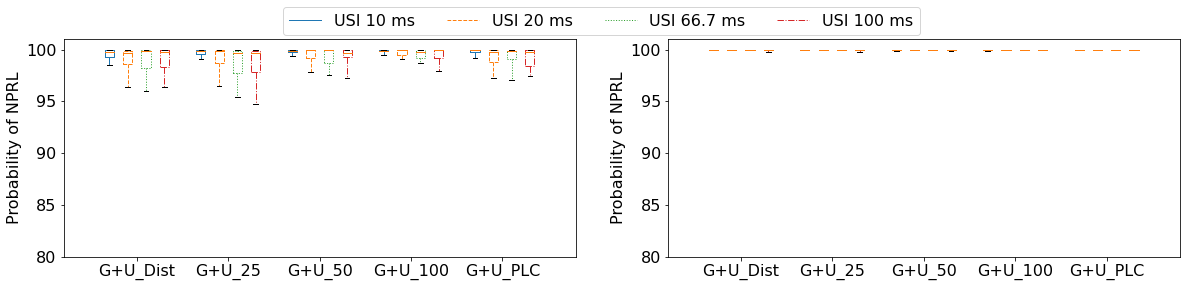

In [6]:
# Plot Percentage of Sim Runs with Consecutive Packet Failures
TH_GCS_PATH = "/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Obj3_Retransmission_Datasets/G+U_PLC_{}_Interference_new"
DV_GCS_PATH = "/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Obj3_Retransmission_Datasets/G+U_Dist_{}_Interference_new"
FP_25_GCS_PATH = "/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Obj3_Retransmission_Datasets/G+U_Fixed25_{}_Interference_new"
FP_50_GCS_PATH = "/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Obj3_Retransmission_Datasets/G+U_Fixed50_{}_Interference_new"
FP_100_GCS_PATH = "/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Obj3_Retransmission_Datasets/G+U_Fixed100_{}_Interference_new"
CASES = ["uav_scenario_0_processed", "uav_scenario_1_processed", "uav_scenario_2_processed",
         "manet_scenario_1_processed", "manet_scenario_a_processed", "manet_scenario_2_processed"]
TEST_CASES = ["UAVSpeed-16_Height-60_BitRate-26", "UAVSpeed-26_Height-150_BitRate-26", "UAVSpeed-26_Height-60_BitRate-65", # These are for UAV scenarios
    "UAVSpeed-16_BitRate-26_Height-60", "UAVSpeed-26_BitRate-26_Height-150", "UAVSpeed-26_BitRate-65_Height-60"] # These are for MANET. They are the same scenarios, the naming convention was different
MAX_RUN_NUM = 499 # Run num starts at 0
START_RUN_NUM = 0
END_RUN_NUM = 499
N_SECS = 2

# To store the percentage of sim runs with no cons packet failures
pm_gcs_result = []
fp_25_gcs_result = []
fp_50_gcs_result = []
fp_100_gcs_result = []
dv_gcs_result = []

for case in CASES:
    if "uav" in case:
        intf_type = "UAV"
    elif "manet" in case:
        intf_type = "MANET"
    # pm_gcs_df = compile_results(TH_GCS_PATH.format(intf_type), [case], MAX_RUN_NUM, "Cons_Fail_{}_period.csv".format(N_SECS))
    # fp_25_gcs_df = compile_results(FP_25_GCS_PATH.format(intf_type), [case], MAX_RUN_NUM, "Cons_Fail_{}_period.csv".format(N_SECS))
    # fp_50_gcs_df = compile_results(FP_50_GCS_PATH.format(intf_type), [case], MAX_RUN_NUM, "Cons_Fail_{}_period.csv".format(N_SECS))
    # fp_100_gcs_df = compile_results(FP_100_GCS_PATH.format(intf_type), [case], MAX_RUN_NUM, "Cons_Fail_{}_period.csv".format(N_SECS))
    # dv_gcs_df = compile_results(DV_GCS_PATH.format(intf_type), [case], MAX_RUN_NUM, "Cons_Fail_{}_period.csv".format(N_SECS))
    '''For Custom Run Num Range'''
    pm_gcs_df = compile_results_range_testcase(TH_GCS_PATH.format(intf_type), [case], START_RUN_NUM, END_RUN_NUM, TEST_CASES, "Cons_Fail_{}_period.csv".format(N_SECS))
    fp_25_gcs_df = compile_results_range_testcase(FP_25_GCS_PATH.format(intf_type), [case], START_RUN_NUM, END_RUN_NUM, TEST_CASES, "Cons_Fail_{}_period.csv".format(N_SECS))
    fp_50_gcs_df = compile_results_range_testcase(FP_50_GCS_PATH.format(intf_type), [case], START_RUN_NUM, END_RUN_NUM, TEST_CASES, "Cons_Fail_{}_period.csv".format(N_SECS))
    fp_100_gcs_df = compile_results_range_testcase(FP_100_GCS_PATH.format(intf_type), [case], START_RUN_NUM, END_RUN_NUM, TEST_CASES, "Cons_Fail_{}_period.csv".format(N_SECS))
    dv_gcs_df = compile_results_range_testcase(DV_GCS_PATH.format(intf_type), [case], START_RUN_NUM, END_RUN_NUM, TEST_CASES, "Cons_Fail_{}_period.csv".format(N_SECS))
    print(len(pm_gcs_df))
    '''Filter out runs where there are NaN results (invalid)'''
    # First, sort all DFs so that their rows are of the same simulation cases
    pm_gcs_df.sort_values(by=["Scenario", "Run"], inplace=True)
    fp_25_gcs_df.sort_values(by=["Scenario", "Run"], inplace=True)
    fp_50_gcs_df.sort_values(by=["Scenario", "Run"], inplace=True)
    fp_100_gcs_df.sort_values(by=["Scenario", "Run"], inplace=True)
    dv_gcs_df.sort_values(by=["Scenario", "Run"], inplace=True)

    pm_gcs_df.reset_index(inplace=True)
    fp_25_gcs_df.reset_index(inplace=True)
    fp_50_gcs_df.reset_index(inplace=True)
    fp_100_gcs_df.reset_index(inplace=True)
    dv_gcs_df.reset_index(inplace=True)

    runs_nan = (pm_gcs_df.isnull().any(axis=1).to_numpy()) | (dv_gcs_df.isnull().any(axis=1).to_numpy()) | \
                (fp_25_gcs_df.isnull().any(axis=1).to_numpy()) | (fp_50_gcs_df.isnull().any(axis=1).to_numpy()) | (fp_100_gcs_df.isnull().any(axis=1).to_numpy())
    pm_gcs_df_fil = pm_gcs_df.loc[~(runs_nan)]
    fp_25_gcs_df_fil = fp_25_gcs_df.loc[~(runs_nan)]
    fp_50_gcs_df_fil = fp_50_gcs_df.loc[~(runs_nan)]
    fp_100_gcs_df_fil = fp_100_gcs_df.loc[~(runs_nan)]
    dv_gcs_df_fil = dv_gcs_df.loc[~(runs_nan)]

    '''For each scheme, For each USI, Get percentages of sim runs with N_SECS consecutive packet failure in at least one link'''
    pm_gcs_result_usi = []
    fp_25_gcs_result_usi = []
    fp_50_gcs_result_usi = []
    fp_100_gcs_result_usi = []
    dv_gcs_result_usi = []

    for usi in ["10", "20", "66.7", "100"]:
        pm_gcs_df_usi = pm_gcs_df_fil.loc[(pm_gcs_df_fil['Scenario'].str.contains("_UAVSendingInterval-{}_".format(usi)))]
        pm_gcs_result_usi.append(len(pm_gcs_df_usi.loc[(pm_gcs_df_usi["UAV_0_Cons_Fail"] == 0) &
                                            (pm_gcs_df_usi["UAV_1_Cons_Fail"] == 0) & (pm_gcs_df_usi["UAV_2_Cons_Fail"] == 0) &
                                            (pm_gcs_df_usi["UAV_3_Cons_Fail"] == 0) & (pm_gcs_df_usi["UAV_4_Cons_Fail"] == 0) & 
                                            (pm_gcs_df_usi["UAV_5_Cons_Fail"] == 0) & (pm_gcs_df_usi["UAV_6_Cons_Fail"] == 0) & 
                                            (pm_gcs_df_usi["UAV_7_Cons_Fail"] == 0)])/len(pm_gcs_df_usi) * 100)
        fp_25_gcs_df_usi = fp_25_gcs_df_fil.loc[(fp_25_gcs_df_fil['Scenario'].str.contains("_UAVSendingInterval-{}_".format(usi)))]
        fp_25_gcs_result_usi.append(len(fp_25_gcs_df_usi.loc[(fp_25_gcs_df_usi["UAV_0_Cons_Fail"] == 0) &
                                            (fp_25_gcs_df_usi["UAV_1_Cons_Fail"] == 0) & (fp_25_gcs_df_usi["UAV_2_Cons_Fail"] == 0) &
                                            (fp_25_gcs_df_usi["UAV_3_Cons_Fail"] == 0) & (fp_25_gcs_df_usi["UAV_4_Cons_Fail"] == 0) & 
                                            (fp_25_gcs_df_usi["UAV_5_Cons_Fail"] == 0) & (fp_25_gcs_df_usi["UAV_6_Cons_Fail"] == 0) & 
                                            (fp_25_gcs_df_usi["UAV_7_Cons_Fail"] == 0)])/len(fp_25_gcs_df_usi) * 100)
        fp_50_gcs_df_usi = fp_50_gcs_df_fil.loc[(fp_50_gcs_df_fil['Scenario'].str.contains("_UAVSendingInterval-{}_".format(usi)))]
        fp_50_gcs_result_usi.append(len(fp_50_gcs_df_usi.loc[(fp_50_gcs_df_usi["UAV_0_Cons_Fail"] == 0) &
                                            (fp_50_gcs_df_usi["UAV_1_Cons_Fail"] == 0) & (fp_50_gcs_df_usi["UAV_2_Cons_Fail"] == 0) &
                                            (fp_50_gcs_df_usi["UAV_3_Cons_Fail"] == 0) & (fp_50_gcs_df_usi["UAV_4_Cons_Fail"] == 0) & 
                                            (fp_50_gcs_df_usi["UAV_5_Cons_Fail"] == 0) & (fp_50_gcs_df_usi["UAV_6_Cons_Fail"] == 0) & 
                                            (fp_50_gcs_df_usi["UAV_7_Cons_Fail"] == 0)])/len(fp_50_gcs_df_usi) * 100)
        fp_100_gcs_df_usi = fp_100_gcs_df_fil.loc[(fp_100_gcs_df_fil['Scenario'].str.contains("_UAVSendingInterval-{}_".format(usi)))]
        fp_100_gcs_result_usi.append(len(fp_100_gcs_df_usi.loc[(fp_100_gcs_df_usi["UAV_0_Cons_Fail"] == 0) &
                                            (fp_100_gcs_df_usi["UAV_1_Cons_Fail"] == 0) & (fp_100_gcs_df_usi["UAV_2_Cons_Fail"] == 0) &
                                            (fp_100_gcs_df_usi["UAV_3_Cons_Fail"] == 0) & (fp_100_gcs_df_usi["UAV_4_Cons_Fail"] == 0) & 
                                            (fp_100_gcs_df_usi["UAV_5_Cons_Fail"] == 0) & (fp_100_gcs_df_usi["UAV_6_Cons_Fail"] == 0) & 
                                            (fp_100_gcs_df_usi["UAV_7_Cons_Fail"] == 0)])/len(fp_100_gcs_df_usi) * 100)
        dv_gcs_df_usi = dv_gcs_df_fil.loc[(dv_gcs_df_fil['Scenario'].str.contains("_UAVSendingInterval-{}_".format(usi)))]
        dv_gcs_result_usi.append(len(dv_gcs_df_usi.loc[(dv_gcs_df_usi["UAV_0_Cons_Fail"] == 0) &
                                            (dv_gcs_df_usi["UAV_1_Cons_Fail"] == 0) & (dv_gcs_df_usi["UAV_2_Cons_Fail"] == 0) &
                                            (dv_gcs_df_usi["UAV_3_Cons_Fail"] == 0) & (dv_gcs_df_usi["UAV_4_Cons_Fail"] == 0) & 
                                            (dv_gcs_df_usi["UAV_5_Cons_Fail"] == 0) & (dv_gcs_df_usi["UAV_6_Cons_Fail"] == 0) & 
                                            (dv_gcs_df_usi["UAV_7_Cons_Fail"] == 0)])/len(dv_gcs_df_usi) * 100)
    
    pm_gcs_result.append(pm_gcs_result_usi)
    fp_25_gcs_result.append(fp_25_gcs_result_usi)
    fp_50_gcs_result.append(fp_50_gcs_result_usi)
    fp_100_gcs_result.append(fp_100_gcs_result_usi)
    dv_gcs_result.append(dv_gcs_result_usi)

pm_gcs_result_box = [[x[i] for x in pm_gcs_result] for i in range(4)]
fp_25_gcs_result_box = [[x[i] for x in fp_25_gcs_result] for i in range(4)]
fp_50_gcs_result_box = [[x[i] for x in fp_50_gcs_result] for i in range(4)]
fp_100_gcs_result_box = [[x[i] for x in fp_100_gcs_result] for i in range(4)]
dv_gcs_result_box = [[x[i] for x in dv_gcs_result] for i in range(4)]

# Plot for nc = 2
plt.rcParams.update({'font.size': 16, 'xtick.labelsize':'medium', 'font.family': 'sans-serif'})
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 4))
space = 0.2
box_params = dict(widths=0.1)
box1 = ax1.boxplot([dv_gcs_result_box[0], fp_25_gcs_result_box[0], fp_50_gcs_result_box[0], fp_100_gcs_result_box[0], pm_gcs_result_box[0]], 
                   showmeans=False, whis=[0, 100], positions=np.arange(5)-1.5*space, 
                   boxprops=dict(linestyle='-', linewidth=1,  color='tab:blue'), 
                   whiskerprops=dict(linestyle='-', linewidth=1, color='tab:blue'), **box_params)
box2 = ax1.boxplot([dv_gcs_result_box[1], fp_25_gcs_result_box[1], fp_50_gcs_result_box[1], fp_100_gcs_result_box[1], pm_gcs_result_box[1]], 
                   showmeans=False, whis=[0, 100], positions=np.arange(5)-0.5*space,
                   boxprops=dict(linestyle='--', linewidth=1,  color='tab:orange'), 
                   whiskerprops=dict(linestyle='--', linewidth=1, color='tab:orange'), **box_params)
box3 = ax1.boxplot([dv_gcs_result_box[2], fp_25_gcs_result_box[2], fp_50_gcs_result_box[2], fp_100_gcs_result_box[2], pm_gcs_result_box[2]], 
                   showmeans=False, whis=[0, 100], positions=np.arange(5)+0.5*space,
                   boxprops=dict(linestyle=':', linewidth=1,  color='tab:green'), 
                   whiskerprops=dict(linestyle=':', linewidth=1, color='tab:green'), **box_params)
box4 = ax1.boxplot([dv_gcs_result_box[3], fp_25_gcs_result_box[3], fp_50_gcs_result_box[3], fp_100_gcs_result_box[3], pm_gcs_result_box[3]], 
                   showmeans=False, whis=[0, 100], positions=np.arange(5)+1.5*space,
                   boxprops=dict(linestyle='dashdot', linewidth=1,  color='tab:red'), 
                   whiskerprops=dict(linestyle='dashdot', linewidth=1, color='tab:red'), **box_params)
ax1.set_ylabel("Probability of NPRL")
ax1.set_ylim(80,101)
ax1.set_xticks(np.arange(5), ["G+U_Dist", "G+U_25", "G+U_50", "G+U_100", "G+U_PLC"], fontsize=16)
ax1.legend((box1["boxes"][0], box2["boxes"][0], box3["boxes"][0], box4["boxes"][0]),
               ["USI 10 ms", "USI 20 ms", "USI 66.7 ms", "USI 100 ms",], bbox_to_anchor=(0.55, 1.02, 1, 0.2), loc="lower center", fontsize=16, borderaxespad=0, ncol=4)

# print("N_C = 2")
# for i in range(len(CASES)):
#     print("{},{},{},{},{}".format(dv_gcs_result[i], fp_25_gcs_result[i], fp_50_gcs_result[i], fp_100_gcs_result[i], pm_gcs_result[i]))

# Now do it for nc of 3
N_SECS = 3

# To store the percentage of sim runs with no cons packet failures
pm_gcs_result = []
fp_25_gcs_result = []
fp_50_gcs_result = []
fp_100_gcs_result = []
dv_gcs_result = []

for case in CASES:
    if "uav" in case:
        intf_type = "UAV"
    elif "manet" in case:
        intf_type = "MANET"
    # pm_gcs_df = compile_results(TH_GCS_PATH.format(intf_type), [case], MAX_RUN_NUM, "Cons_Fail_{}_period.csv".format(N_SECS))
    # fp_25_gcs_df = compile_results(FP_25_GCS_PATH.format(intf_type), [case], MAX_RUN_NUM, "Cons_Fail_{}_period.csv".format(N_SECS))
    # fp_50_gcs_df = compile_results(FP_50_GCS_PATH.format(intf_type), [case], MAX_RUN_NUM, "Cons_Fail_{}_period.csv".format(N_SECS))
    # fp_100_gcs_df = compile_results(FP_100_GCS_PATH.format(intf_type), [case], MAX_RUN_NUM, "Cons_Fail_{}_period.csv".format(N_SECS))
    # dv_gcs_df = compile_results(DV_GCS_PATH.format(intf_type), [case], MAX_RUN_NUM, "Cons_Fail_{}_period.csv".format(N_SECS))
    '''For Custom Run Num Range'''
    pm_gcs_df = compile_results_range_testcase(TH_GCS_PATH.format(intf_type), [case], START_RUN_NUM, END_RUN_NUM, TEST_CASES, "Cons_Fail_{}_period.csv".format(N_SECS))
    fp_25_gcs_df = compile_results_range_testcase(FP_25_GCS_PATH.format(intf_type), [case], START_RUN_NUM, END_RUN_NUM, TEST_CASES, "Cons_Fail_{}_period.csv".format(N_SECS))
    fp_50_gcs_df = compile_results_range_testcase(FP_50_GCS_PATH.format(intf_type), [case], START_RUN_NUM, END_RUN_NUM, TEST_CASES, "Cons_Fail_{}_period.csv".format(N_SECS))
    fp_100_gcs_df = compile_results_range_testcase(FP_100_GCS_PATH.format(intf_type), [case], START_RUN_NUM, END_RUN_NUM, TEST_CASES, "Cons_Fail_{}_period.csv".format(N_SECS))
    dv_gcs_df = compile_results_range_testcase(DV_GCS_PATH.format(intf_type), [case], START_RUN_NUM, END_RUN_NUM, TEST_CASES, "Cons_Fail_{}_period.csv".format(N_SECS))
    print(len(pm_gcs_df))
    '''Filter out runs where there are NaN results (invalid)'''
    # First, sort all DFs so that their rows are of the same simulation cases
    pm_gcs_df.sort_values(by=["Scenario", "Run"], inplace=True)
    fp_25_gcs_df.sort_values(by=["Scenario", "Run"], inplace=True)
    fp_50_gcs_df.sort_values(by=["Scenario", "Run"], inplace=True)
    fp_100_gcs_df.sort_values(by=["Scenario", "Run"], inplace=True)
    dv_gcs_df.sort_values(by=["Scenario", "Run"], inplace=True)

    pm_gcs_df.reset_index(inplace=True)
    fp_25_gcs_df.reset_index(inplace=True)
    fp_50_gcs_df.reset_index(inplace=True)
    fp_100_gcs_df.reset_index(inplace=True)
    dv_gcs_df.reset_index(inplace=True)

    runs_nan = (pm_gcs_df.isnull().any(axis=1).to_numpy()) | (dv_gcs_df.isnull().any(axis=1).to_numpy()) | \
                (fp_25_gcs_df.isnull().any(axis=1).to_numpy()) | (fp_50_gcs_df.isnull().any(axis=1).to_numpy()) | (fp_100_gcs_df.isnull().any(axis=1).to_numpy())
    pm_gcs_df_fil = pm_gcs_df.loc[~(runs_nan)]
    fp_25_gcs_df_fil = fp_25_gcs_df.loc[~(runs_nan)]
    fp_50_gcs_df_fil = fp_50_gcs_df.loc[~(runs_nan)]
    fp_100_gcs_df_fil = fp_100_gcs_df.loc[~(runs_nan)]
    dv_gcs_df_fil = dv_gcs_df.loc[~(runs_nan)]

    '''For each scheme, For each USI, Get percentages of sim runs with N_SECS consecutive packet failure in at least one link'''
    pm_gcs_result_usi = []
    fp_25_gcs_result_usi = []
    fp_50_gcs_result_usi = []
    fp_100_gcs_result_usi = []
    dv_gcs_result_usi = []

    for usi in ["10", "20", "66.7", "100"]:
        pm_gcs_df_usi = pm_gcs_df_fil.loc[(pm_gcs_df_fil['Scenario'].str.contains("_UAVSendingInterval-{}_".format(usi)))]
        pm_gcs_result_usi.append(len(pm_gcs_df_usi.loc[(pm_gcs_df_usi["UAV_0_Cons_Fail"] == 0) &
                                            (pm_gcs_df_usi["UAV_1_Cons_Fail"] == 0) & (pm_gcs_df_usi["UAV_2_Cons_Fail"] == 0) &
                                            (pm_gcs_df_usi["UAV_3_Cons_Fail"] == 0) & (pm_gcs_df_usi["UAV_4_Cons_Fail"] == 0) & 
                                            (pm_gcs_df_usi["UAV_5_Cons_Fail"] == 0) & (pm_gcs_df_usi["UAV_6_Cons_Fail"] == 0) & 
                                            (pm_gcs_df_usi["UAV_7_Cons_Fail"] == 0)])/len(pm_gcs_df_usi) * 100)
        fp_25_gcs_df_usi = fp_25_gcs_df_fil.loc[(fp_25_gcs_df_fil['Scenario'].str.contains("_UAVSendingInterval-{}_".format(usi)))]
        fp_25_gcs_result_usi.append(len(fp_25_gcs_df_usi.loc[(fp_25_gcs_df_usi["UAV_0_Cons_Fail"] == 0) &
                                            (fp_25_gcs_df_usi["UAV_1_Cons_Fail"] == 0) & (fp_25_gcs_df_usi["UAV_2_Cons_Fail"] == 0) &
                                            (fp_25_gcs_df_usi["UAV_3_Cons_Fail"] == 0) & (fp_25_gcs_df_usi["UAV_4_Cons_Fail"] == 0) & 
                                            (fp_25_gcs_df_usi["UAV_5_Cons_Fail"] == 0) & (fp_25_gcs_df_usi["UAV_6_Cons_Fail"] == 0) & 
                                            (fp_25_gcs_df_usi["UAV_7_Cons_Fail"] == 0)])/len(fp_25_gcs_df_usi) * 100)
        fp_50_gcs_df_usi = fp_50_gcs_df_fil.loc[(fp_50_gcs_df_fil['Scenario'].str.contains("_UAVSendingInterval-{}_".format(usi)))]
        fp_50_gcs_result_usi.append(len(fp_50_gcs_df_usi.loc[(fp_50_gcs_df_usi["UAV_0_Cons_Fail"] == 0) &
                                            (fp_50_gcs_df_usi["UAV_1_Cons_Fail"] == 0) & (fp_50_gcs_df_usi["UAV_2_Cons_Fail"] == 0) &
                                            (fp_50_gcs_df_usi["UAV_3_Cons_Fail"] == 0) & (fp_50_gcs_df_usi["UAV_4_Cons_Fail"] == 0) & 
                                            (fp_50_gcs_df_usi["UAV_5_Cons_Fail"] == 0) & (fp_50_gcs_df_usi["UAV_6_Cons_Fail"] == 0) & 
                                            (fp_50_gcs_df_usi["UAV_7_Cons_Fail"] == 0)])/len(fp_50_gcs_df_usi) * 100)
        fp_100_gcs_df_usi = fp_100_gcs_df_fil.loc[(fp_100_gcs_df_fil['Scenario'].str.contains("_UAVSendingInterval-{}_".format(usi)))]
        fp_100_gcs_result_usi.append(len(fp_100_gcs_df_usi.loc[(fp_100_gcs_df_usi["UAV_0_Cons_Fail"] == 0) &
                                            (fp_100_gcs_df_usi["UAV_1_Cons_Fail"] == 0) & (fp_100_gcs_df_usi["UAV_2_Cons_Fail"] == 0) &
                                            (fp_100_gcs_df_usi["UAV_3_Cons_Fail"] == 0) & (fp_100_gcs_df_usi["UAV_4_Cons_Fail"] == 0) & 
                                            (fp_100_gcs_df_usi["UAV_5_Cons_Fail"] == 0) & (fp_100_gcs_df_usi["UAV_6_Cons_Fail"] == 0) & 
                                            (fp_100_gcs_df_usi["UAV_7_Cons_Fail"] == 0)])/len(fp_100_gcs_df_usi) * 100)
        dv_gcs_df_usi = dv_gcs_df_fil.loc[(dv_gcs_df_fil['Scenario'].str.contains("_UAVSendingInterval-{}_".format(usi)))]
        dv_gcs_result_usi.append(len(dv_gcs_df_usi.loc[(dv_gcs_df_usi["UAV_0_Cons_Fail"] == 0) &
                                            (dv_gcs_df_usi["UAV_1_Cons_Fail"] == 0) & (dv_gcs_df_usi["UAV_2_Cons_Fail"] == 0) &
                                            (dv_gcs_df_usi["UAV_3_Cons_Fail"] == 0) & (dv_gcs_df_usi["UAV_4_Cons_Fail"] == 0) & 
                                            (dv_gcs_df_usi["UAV_5_Cons_Fail"] == 0) & (dv_gcs_df_usi["UAV_6_Cons_Fail"] == 0) & 
                                            (dv_gcs_df_usi["UAV_7_Cons_Fail"] == 0)])/len(dv_gcs_df_usi) * 100)
    
    pm_gcs_result.append(pm_gcs_result_usi)
    fp_25_gcs_result.append(fp_25_gcs_result_usi)
    fp_50_gcs_result.append(fp_50_gcs_result_usi)
    fp_100_gcs_result.append(fp_100_gcs_result_usi)
    dv_gcs_result.append(dv_gcs_result_usi)

pm_gcs_result_box = [[x[i] for x in pm_gcs_result] for i in range(4)]
fp_25_gcs_result_box = [[x[i] for x in fp_25_gcs_result] for i in range(4)]
fp_50_gcs_result_box = [[x[i] for x in fp_50_gcs_result] for i in range(4)]
fp_100_gcs_result_box = [[x[i] for x in fp_100_gcs_result] for i in range(4)]
dv_gcs_result_box = [[x[i] for x in dv_gcs_result] for i in range(4)]
    
space = 0.2
box_params = dict(widths=0.1)
box1 = ax2.boxplot([dv_gcs_result_box[0], fp_25_gcs_result_box[0], fp_50_gcs_result_box[0], fp_100_gcs_result_box[0], pm_gcs_result_box[0]], 
                   showmeans=False, whis=[0, 100], positions=np.arange(5)-1.5*space, 
                   boxprops=dict(linestyle='-', linewidth=1,  color='tab:blue'), 
                   whiskerprops=dict(linestyle='-', linewidth=1, color='tab:blue'), **box_params)
box2 = ax2.boxplot([dv_gcs_result_box[1], fp_25_gcs_result_box[1], fp_50_gcs_result_box[1], fp_100_gcs_result_box[1], pm_gcs_result_box[1]], 
                   showmeans=False, whis=[0, 100], positions=np.arange(5)-0.5*space,
                   boxprops=dict(linestyle='--', linewidth=1,  color='tab:orange'), 
                   whiskerprops=dict(linestyle='--', linewidth=1, color='tab:orange'), **box_params)
box3 = ax2.boxplot([dv_gcs_result_box[2], fp_25_gcs_result_box[2], fp_50_gcs_result_box[2], fp_100_gcs_result_box[2], pm_gcs_result_box[2]], 
                   showmeans=False, whis=[0, 100], positions=np.arange(5)+0.5*space,
                   boxprops=dict(linestyle=':', linewidth=1,  color='tab:green'), 
                   whiskerprops=dict(linestyle=':', linewidth=1, color='tab:green'), **box_params)
box4 = ax2.boxplot([dv_gcs_result_box[3], fp_25_gcs_result_box[3], fp_50_gcs_result_box[3], fp_100_gcs_result_box[3], pm_gcs_result_box[3]], 
                   showmeans=False, whis=[0, 100], positions=np.arange(5)+1.5*space,
                   boxprops=dict(linestyle='dashdot', linewidth=1,  color='tab:red'), 
                   whiskerprops=dict(linestyle='dashdot', linewidth=1, color='tab:red'), **box_params)
ax2.set_ylabel("Probability of NPRL")
ax2.set_ylim(80,101)
ax2.set_xticks(np.arange(5), ["G+U_Dist", "G+U_25", "G+U_50", "G+U_100", "G+U_PLC"], fontsize=16)

plt.subplots_adjust(wspace=0.18)

# print("N_C = 3")
# for i in range(len(CASES)):
#     print("{},{},{},{},{}".format(dv_gcs_result[i], fp_25_gcs_result[i], fp_50_gcs_result[i], fp_100_gcs_result[i], pm_gcs_result[i]))

## Is it due to a difference in Dmax?

348
1052
1200
1088
1191
1199


348
1052
1200
1088
1191
1199


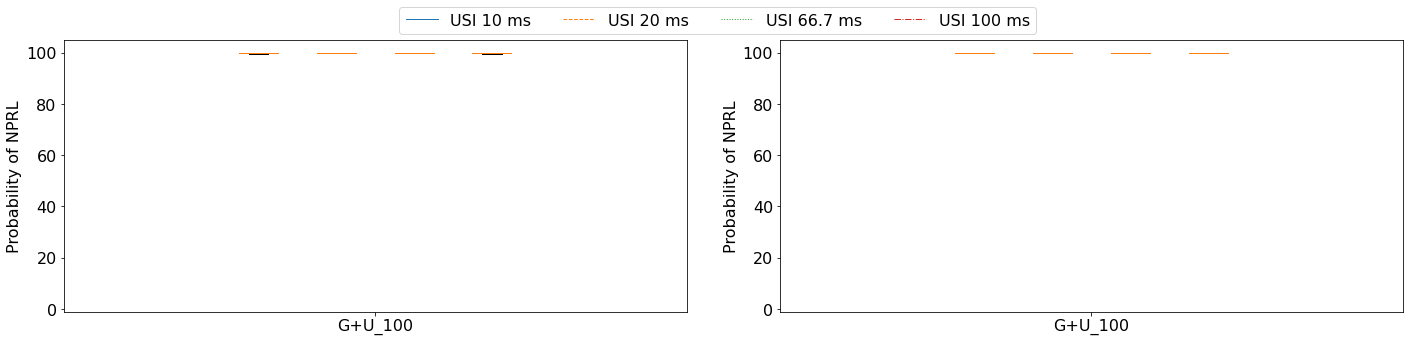

In [5]:
# Simulated the following with Dmax of 100 m for all test cases
# Plot Percentage of Sim Runs with Consecutive Packet Failures
FP_100_PATH = "/media/research-student/DataDrive/FANET_Dataset/DJISpark_Obj3_Retransmission_Datasets/G+U_Fixed100_{}_Interference_Dmax100"
CASES = ["uav_scenario_0_processed", "uav_scenario_1_processed", "uav_scenario_2_processed",
         "manet_scenario_1_processed", "manet_scenario_a_processed", "manet_scenario_2_processed"]
TEST_CASES = ["UAVSpeed-16_Height-60_BitRate-26", "UAVSpeed-26_Height-150_BitRate-26", "UAVSpeed-26_Height-60_BitRate-65", # These are for UAV scenarios
              "UAVSpeed-16_BitRate-26_Height-60", "UAVSpeed-26_BitRate-26_Height-150", "UAVSpeed-26_BitRate-65_Height-60"] # These are for MANET. They are the same scenarios, the naming convention was different
MAX_RUN_NUM = 499 # Run num starts at 0
START_RUN_NUM = 0
END_RUN_NUM = 499
N_SECS = 2

# To store the percentage of sim runs with no cons packet failures
fp_100_result = []
# pm_gcs_result = []

for case in CASES:
    if "uav" in case:
        intf_type = "UAV"
    elif "manet" in case:
        intf_type = "MANET"
    # manual_df = compile_results(MANUAL_PATH.format(intf_type), [case], MAX_RUN_NUM, "Cons_Fail_{}_period.csv".format(N_SECS))
    # waypoint_df = compile_results(WAYPOINT_PATH.format(intf_type), [case], MAX_RUN_NUM, "Cons_Fail_{}_period.csv".format(N_SECS))
    # fp_25_df = compile_results(FP_25_PATH.format(intf_type), [case], MAX_RUN_NUM, "Cons_Fail_{}_period.csv".format(N_SECS))
    # fp_50_df = compile_results(FP_50_PATH.format(intf_type), [case], MAX_RUN_NUM, "Cons_Fail_{}_period.csv".format(N_SECS))
    # fp_100_df = compile_results(FP_100_PATH.format(intf_type), [case], MAX_RUN_NUM, "Cons_Fail_{}_period.csv".format(N_SECS))
    # dv_df = compile_results(DV_PATH.format(intf_type), [case], MAX_RUN_NUM, "Cons_Fail_{}_period.csv".format(N_SECS))
    # pm_df = compile_results(TH_PATH.format(intf_type), [case], MAX_RUN_NUM, "Cons_Fail_{}_period.csv".format(N_SECS))
    '''For Custom Run Num Range'''
    fp_100_df = compile_results_range_testcase(FP_100_PATH.format(intf_type), [case], START_RUN_NUM, END_RUN_NUM, TEST_CASES, "Cons_Fail_{}_period.csv".format(N_SECS))
    print(len(fp_100_df))
    '''Filter out runs where there are NaN results (invalid)'''
    # First, sort all DFs so that their rows are of the same simulation cases
    fp_100_df.sort_values(by=["Scenario", "Run"], inplace=True)
    # pm_gcs_df.sort_values(by=["Scenario", "Run"], inplace=True)

    fp_100_df.reset_index(inplace=True)
    # pm_gcs_df.reset_index(inplace=True)

    runs_nan = (fp_100_df.isnull().any(axis=1).to_numpy()) 
    fp_100_df_fil = fp_100_df.loc[~(runs_nan)]

    '''For each scheme, for each USI, Get percentages of sim runs with N_SECS consecutive packet failure in at least one uplink'''
    fp_100_result_usi = []
    for usi in ["10", "20", "66.7", "100"]:
        
        fp_100_df_usi = fp_100_df_fil.loc[(fp_100_df_fil['Scenario'].str.contains("_UAVSendingInterval-{}_".format(usi)))]
        fp_100_result_usi.append(len(fp_100_df_usi.loc[(fp_100_df_usi["UAV_0_Cons_Fail"] == 0) &
                                            (fp_100_df_usi["UAV_1_Cons_Fail"] == 0) & (fp_100_df_usi["UAV_2_Cons_Fail"] == 0) &
                                            (fp_100_df_usi["UAV_3_Cons_Fail"] == 0) & (fp_100_df_usi["UAV_4_Cons_Fail"] == 0) & 
                                            (fp_100_df_usi["UAV_5_Cons_Fail"] == 0) & (fp_100_df_usi["UAV_6_Cons_Fail"] == 0) & 
                                            (fp_100_df_usi["UAV_7_Cons_Fail"] == 0)])/len(fp_100_df_usi) * 100)

    fp_100_result.append(fp_100_result_usi)

fp_100_result_box = [[x[i] for x in fp_100_result] for i in range(4)]

# Plot for nc = 2
plt.rcParams.update({'font.size': 16, 'xtick.labelsize':'medium', 'font.family': 'sans-serif'})
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(24, 5))
space = 0.2
box_params = dict(widths=0.1)
box1 = ax1.boxplot([fp_100_result_box[0]], 
                   showmeans=False, whis=[0, 100], positions=np.arange(1)-1.5*space, 
                   boxprops=dict(linestyle='-', linewidth=1,  color='tab:blue'), 
                   whiskerprops=dict(linestyle='-', linewidth=1, color='tab:blue'), **box_params)
box2 = ax1.boxplot([fp_100_result_box[1]], 
                   showmeans=False, whis=[0, 100], positions=np.arange(1)-0.5*space,
                   boxprops=dict(linestyle='--', linewidth=1,  color='tab:orange'), 
                   whiskerprops=dict(linestyle='--', linewidth=1, color='tab:orange'), **box_params)
box3 = ax1.boxplot([fp_100_result_box[2]], 
                   showmeans=False, whis=[0, 100], positions=np.arange(1)+0.5*space,
                   boxprops=dict(linestyle=':', linewidth=1,  color='tab:green'), 
                   whiskerprops=dict(linestyle=':', linewidth=1, color='tab:green'), **box_params)
box4 = ax1.boxplot([fp_100_result_box[3]], 
                   showmeans=False, whis=[0, 100], positions=np.arange(1)+1.5*space,
                   boxprops=dict(linestyle='dashdot', linewidth=1,  color='tab:red'), 
                   whiskerprops=dict(linestyle='dashdot', linewidth=1, color='tab:red'), **box_params)
ax1.set_ylabel("Probability of NPRL")
ax1.set_ylim(-1,105)
ax1.set_xticks(np.arange(1), ["G+U_100"], fontsize=16)
ax1.legend((box1["boxes"][0], box2["boxes"][0], box3["boxes"][0], box4["boxes"][0]),
               ["USI 10 ms", "USI 20 ms", "USI 66.7 ms", "USI 100 ms",], bbox_to_anchor=(0.55, 1.02, 1, 0.2), loc="lower center", fontsize=16, borderaxespad=0, ncol=8)

# print("N_C = 2")
# for i in range(len(CASES)):
#     print("{},{},{},{},{},{},{}".format(manual_result[i], waypoint_result[i], dv_result[i], fp_25_result[i], fp_50_result[i], fp_100_result[i], pm_result[i]))

# Now do it for nc of 3
N_SECS = 3

# To store the percentage of sim runs with no cons packet failures
fp_100_result = []

for case in CASES:
    if "uav" in case:
        intf_type = "UAV"
    elif "manet" in case:
        intf_type = "MANET"
    # manual_df = compile_results(MANUAL_PATH.format(intf_type), [case], MAX_RUN_NUM, "Cons_Fail_{}_period.csv".format(N_SECS))
    # waypoint_df = compile_results(WAYPOINT_PATH.format(intf_type), [case], MAX_RUN_NUM, "Cons_Fail_{}_period.csv".format(N_SECS))
    # fp_25_df = compile_results(FP_25_PATH.format(intf_type), [case], MAX_RUN_NUM, "Cons_Fail_{}_period.csv".format(N_SECS))
    # fp_50_df = compile_results(FP_50_PATH.format(intf_type), [case], MAX_RUN_NUM, "Cons_Fail_{}_period.csv".format(N_SECS))
    # fp_100_df = compile_results(FP_100_PATH.format(intf_type), [case], MAX_RUN_NUM, "Cons_Fail_{}_period.csv".format(N_SECS))
    # dv_df = compile_results(DV_PATH.format(intf_type), [case], MAX_RUN_NUM, "Cons_Fail_{}_period.csv".format(N_SECS))
    # pm_df = compile_results(TH_PATH.format(intf_type), [case], MAX_RUN_NUM, "Cons_Fail_{}_period.csv".format(N_SECS))
    '''For Custom Run Num Range'''
    fp_100_df = compile_results_range_testcase(FP_100_PATH.format(intf_type), [case], START_RUN_NUM, END_RUN_NUM, TEST_CASES, "Cons_Fail_{}_period.csv".format(N_SECS))
    print(len(fp_100_df))
    '''Filter out runs where there are NaN results (invalid)'''
    # First, sort all DFs so that their rows are of the same simulation cases
    fp_100_df.sort_values(by=["Scenario", "Run"], inplace=True)
    # pm_gcs_df.sort_values(by=["Scenario", "Run"], inplace=True)

    fp_100_df.reset_index(inplace=True)
    # pm_gcs_df.reset_index(inplace=True)

    runs_nan = (fp_100_df.isnull().any(axis=1).to_numpy())
    fp_100_df_fil = fp_100_df.loc[~(runs_nan)]
    # pm_gcs_df_fil = pm_gcs_df.loc[~(runs_nan)]

    '''For each scheme, for each USI, Get percentages of sim runs with N_SECS consecutive packet failure in at least one uplink'''
    fp_100_result_usi = []
    for usi in ["10", "20", "66.7", "100"]:
        fp_100_df_usi = fp_100_df_fil.loc[(fp_100_df_fil['Scenario'].str.contains("_UAVSendingInterval-{}_".format(usi)))]
        fp_100_result_usi.append(len(fp_100_df_usi.loc[(fp_100_df_usi["UAV_0_Cons_Fail"] == 0) &
                                            (fp_100_df_usi["UAV_1_Cons_Fail"] == 0) & (fp_100_df_usi["UAV_2_Cons_Fail"] == 0) &
                                            (fp_100_df_usi["UAV_3_Cons_Fail"] == 0) & (fp_100_df_usi["UAV_4_Cons_Fail"] == 0) & 
                                            (fp_100_df_usi["UAV_5_Cons_Fail"] == 0) & (fp_100_df_usi["UAV_6_Cons_Fail"] == 0) & 
                                            (fp_100_df_usi["UAV_7_Cons_Fail"] == 0)])/len(fp_100_df_usi) * 100)

    fp_100_result.append(fp_100_result_usi)

fp_100_result_box = [[x[i] for x in fp_100_result] for i in range(4)]

    
space = 0.2
box_params = dict(widths=0.1)
box1 = ax2.boxplot([fp_100_result_box[0]], 
                   showmeans=False, whis=[0, 100], positions=np.arange(1)-1.5*space, 
                   boxprops=dict(linestyle='-', linewidth=1,  color='tab:blue'), 
                   whiskerprops=dict(linestyle='-', linewidth=1, color='tab:blue'), **box_params)
box2 = ax2.boxplot([fp_100_result_box[1]], 
                   showmeans=False, whis=[0, 100], positions=np.arange(1)-0.5*space,
                   boxprops=dict(linestyle='--', linewidth=1,  color='tab:orange'), 
                   whiskerprops=dict(linestyle='--', linewidth=1, color='tab:orange'), **box_params)
box3 = ax2.boxplot([fp_100_result_box[2]], 
                   showmeans=False, whis=[0, 100], positions=np.arange(1)+0.5*space,
                   boxprops=dict(linestyle=':', linewidth=1,  color='tab:green'), 
                   whiskerprops=dict(linestyle=':', linewidth=1, color='tab:green'), **box_params)
box4 = ax2.boxplot([fp_100_result_box[3]], 
                   showmeans=False, whis=[0, 100], positions=np.arange(1)+1.5*space,
                   boxprops=dict(linestyle='dashdot', linewidth=1,  color='tab:red'), 
                   whiskerprops=dict(linestyle='dashdot', linewidth=1, color='tab:red'), **box_params)
ax2.set_ylabel("Probability of NPRL")
ax2.set_ylim(-1,105)
ax2.set_xticks(np.arange(1), ["G+U_100"], fontsize=16)
# ax1.legend((box1["boxes"][0], box2["boxes"][0], box3["boxes"][0], box4["boxes"][0]),
#                ["USI 10 ms", "USI 20 ms", "USI 66.7 ms", "USI 100 ms",], bbox_to_anchor=(0, 1.02, 1, 0.2), loc="lower center", fontsize=12, borderaxespad=0, ncol=8)

plt.subplots_adjust(wspace=0.15)

# print("N_C = 3")
# for i in range(len(CASES)):
#     print("{},{},{},{},{},{},{}".format(manual_result[i], waypoint_result[i], dv_result[i], fp_25_result[i], fp_50_result[i], fp_100_result[i], pm_result[i]))